In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu

In [5]:
df=pd.read_table('BOR2_313-BOR1_TD_leafB.txt', header=None)
df

,0,1,2,3
0,12768,96.680330,1,0
1,12909,68.320123,0,0
2,12910,83.270692,1,0
3,12915,92.478577,1,0
4,13181,65.550355,0,0
...,...,...,...,...
121,3968_BW,54.849751,0,0
122,3968_BX,92.021164,1,0
123,3968_BY,93.641845,1,0
124,3968_BZ,101.476046,.,0


In [6]:
df=df.rename(columns={0:"Accession", 1:"B", 2:"BOR2", 3:"BOR1"})
df

,Accession,B,BOR2,BOR1
0,12768,96.680330,1,0
1,12909,68.320123,0,0
2,12910,83.270692,1,0
3,12915,92.478577,1,0
4,13181,65.550355,0,0
...,...,...,...,...
121,3968_BW,54.849751,0,0
122,3968_BX,92.021164,1,0
123,3968_BY,93.641845,1,0
124,3968_BZ,101.476046,.,0


In [16]:
mannwhitneyu(df[(df['BOR1'] == 0 ) & (df['BOR2'] == '0')].B,df[(df['BOR1'] == 1 ) & (df['BOR2'] == '0')].B)

MannwhitneyuResult(statistic=5.0, pvalue=6.0464947506178424e-09)

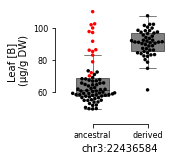

In [8]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})
Order=['0','1']
@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(5*cm,5*cm))
ax=sns.boxplot(x='BOR2', 
            y='B',
            data=df,
            order=Order,
            color='grey',
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
ax=sns.swarmplot(x='BOR2', 
            y='B',
            data=df,
            hue='BOR1',
            order=Order,
            color='0',
            s=3.5,
            palette=["0", "red"])
# ax.yaxis.set_major_locator(ticker.MultipleLocator(300))
sns.despine(trim=True,offset=10)
ax.set_xticklabels(['ancestral', 'derived'])
plt.tick_params(labelsize=8)
plt.legend('',frameon=False)
# plt.xlabel('$\itCNNM1$ L77fs',fontsize=10)
plt.xlabel('chr3:22436584',fontsize=10)
plt.ylabel('Leaf [B] \n(µg/g DW)',fontsize=10)
# plt.savefig("Fig5b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
# plt.savefig("Fig5b.svg", format="svg",bbox_inches="tight",facecolor="w")
plt.savefig("Fig5b.pdf", format="pdf",bbox_inches="tight")